In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [34]:
import numpy as np
import polars as pl

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

In [4]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], descriptors=["ewald"])
df = mp.load()

2026-04-30 16:53:56.058 | INFO     | src.datasets:load:1998 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-30 16:53:57.720 | INFO     | src.datasets:_add_descriptors:2371 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-30 16:53:57.721 | INFO     | src.datasets:_add_descriptors:2408 - Calculating max atoms for Ewald Sum Matrix padding...
2026-04-30 16:53:58.281 | INFO     | src.datasets:_add_descriptors:2456 - Computing Ewald Sum Matrix chunk 0 (0 to 1000)...
2026-04-30 16:54:08.055 | INFO     | src.datasets:_add_descriptors:2456 - Computing Ewald Sum Matrix chunk 1 (1000 to 2000)...
2026-04-30 16:54:17.733 | INFO     | src.datasets:_add_descriptors:2456 - Computing Ewald Sum Matrix chunk 2 (2000 to 3000)...
2026-04-30 16:54:29.318 | INFO     | src.datasets:_add_descriptors:2456 - Computing Ewald Sum Matrix chunk 3 (3000 to 4000)...
2026-04-30 16:54:39.227 | INFO     | src.dat

In [5]:
dist_matrix = mp.get_distance_matrix(
    descriptor="ewald",
    dist_type="euclidean",
    pca_components=4,
    force_calculate=True,
)

2026-04-30 16:55:25.174 | INFO     | src.datasets:get_distance_matrix:2750 - Applying PCA to reduce 'ewald_matrix' to 4 dimensions.
2026-04-30 16:55:26.340 | INFO     | src.datasets:get_distance_matrix:2756 - PCA kept 48.44% of the variance for 'ewald_matrix'.
2026-04-30 16:55:26.340 | INFO     | src.datasets:get_distance_matrix:2758 - PCA reduced 'ewald_matrix' dimensions from 10000 to 4
2026-04-30 16:55:26.379 | INFO     | src.datasets:get_distance_matrix:2776 - Calculating distance matrix for ewald_matrix using euclidean distance.
2026-04-30 16:55:26.714 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/Materials Project/dist_ewald_matrix_euclidean_pca4.npy


# Hierarchical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_93973/907539321.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2, 3, 4, 5], dtype=int32), array([   1,    1,    2,    3, 4993]))


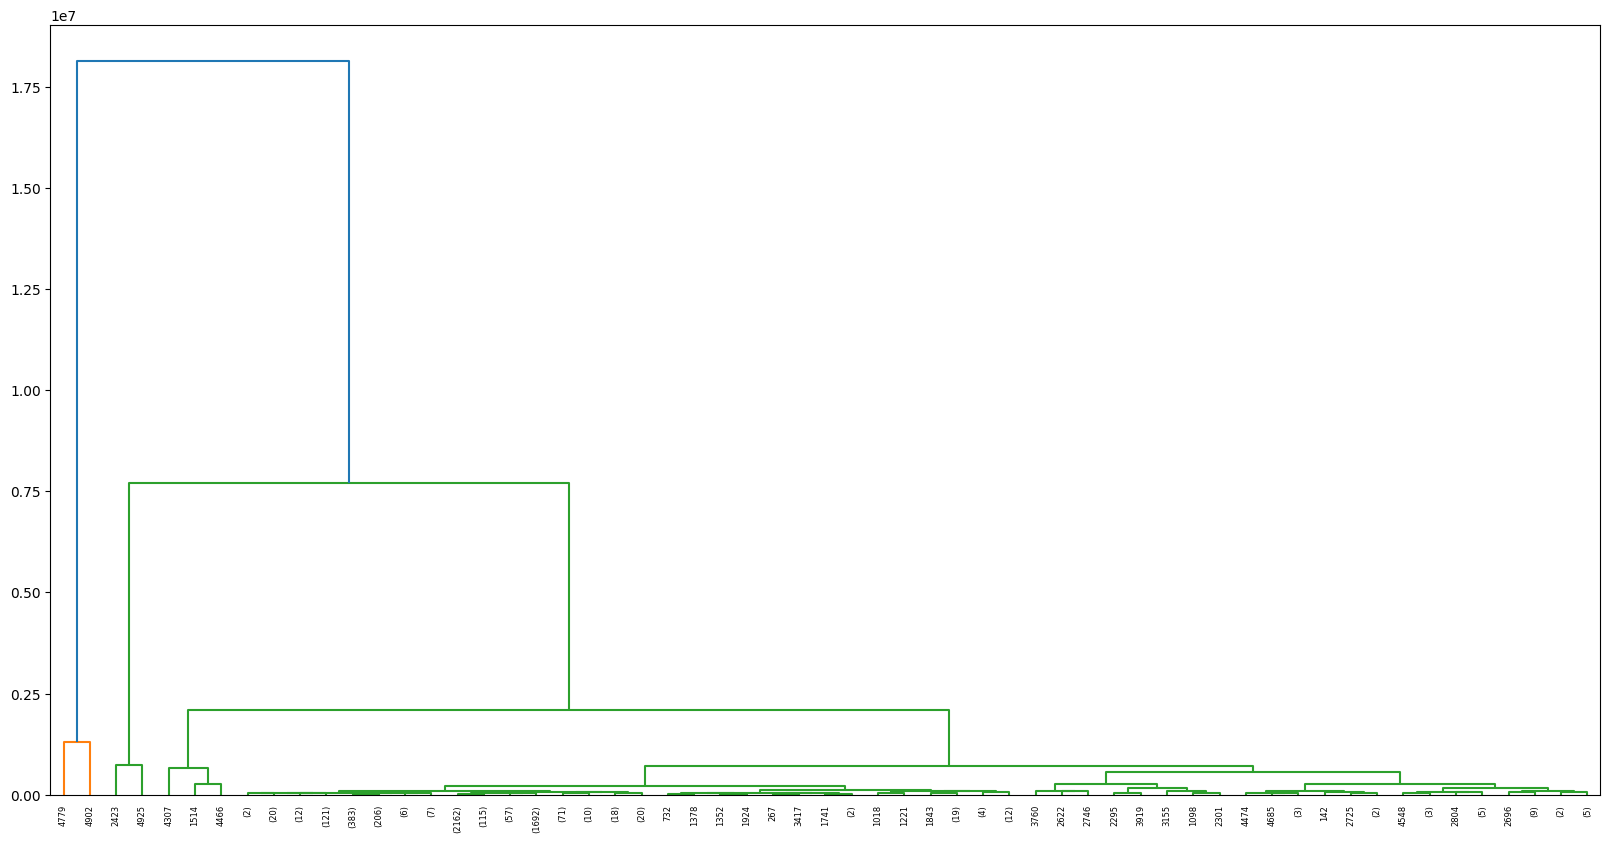

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=8, truncate_mode='level')
labels_hier = fcluster(link, t=1e6, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [7]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (5, 35)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬──────────┬─────────┬─────────┬──────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c        ┆ alpha   ┆ beta    ┆ gamma    ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_

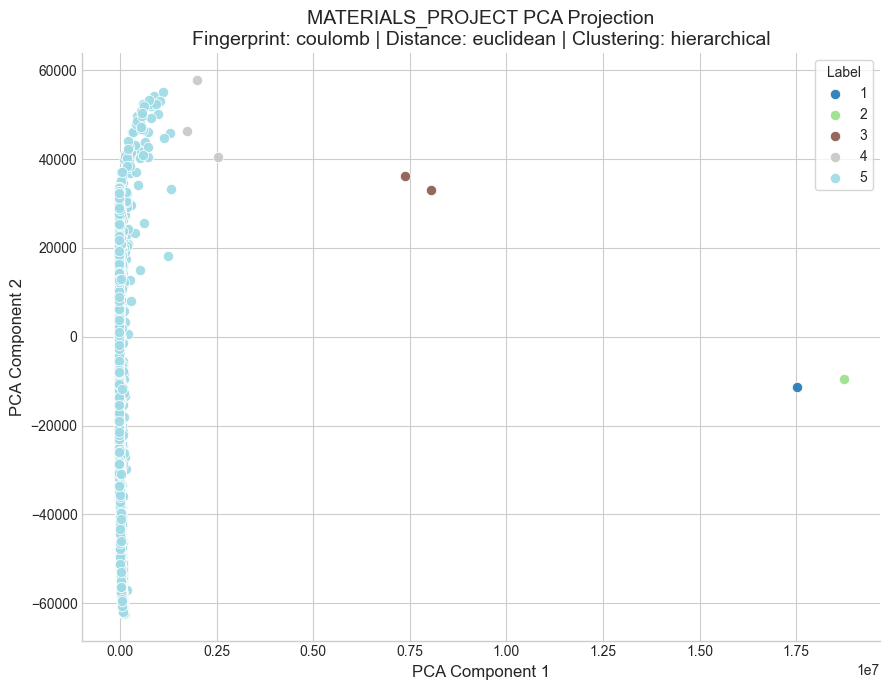

2026-04-30 16:57:59.773 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_hierarchical_projection.png


In [28]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [9]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-04-30 16:56:01.975 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-30 16:56:01.985 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-30 16:56:05.591 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-30 16:56:05.604 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-30 16:56:06.261 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-04-30 16:56:06.443 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [30]:
model_km = KMedoids(n_clusters=4, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2, 3], dtype=uint64), array([ 984,    1, 2289, 1726]))


In [31]:
average_numeric_by_cluster(df, "labels_km")

shape: (4, 37)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬─────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma    ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier ┆ labels_db ┆ pct_metal ┆ unique_crystal_systems ┆ top_cry

labels_km,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,is_injected,labels_hier,labels_db,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,984,1.228862,-25.836528,-0.958077,0.261115,10.26233,6.874542,7.190266,7.655449,86.945909,86.506385,89.253322,336.706869,17.807927,0.036348,2.56462,2.749357,0.0,5.0,0.0,80.182927,7,"""Orthorhombic""",24.288618,110,"""Fm-3m""",6.808943,272,"""ABC2""",7.113821,252,"""cF16""",5.691057,1,null,0.0
1,1,0.97,-2.162634,-0.826622,2.4082,5.377009,4.2853661,4.285366,92.445788,90.0,90.0,119.999992,1470.258351,39.0,0.000462,3.013937,3.018114,0.0,2.0,-1.0,0.0,1,"""Trigonal""",100.0,1,"""P3m1""",100.0,1,"""AB2""",100.0,1,"""hP39""",100.0,1,null,0.0
2,2289,1.808458,-8.266131,-1.502596,0.696413,4.193367,6.606809,7.155138,10.60387,86.842362,88.012264,89.359201,405.73158,27.179991,0.115008,2.106356,2.413512,0.0,4.995194,-0.003495,48.318043,7,"""Monoclinic""",25.294889,147,"""P1""",11.358672,654,"""ABC2""",4.06291,468,"""hP12""",2.096986,1,null,0.0
3,1726,1.463644,-13.745265,-1.216998,0.497979,6.753843,6.601304,7.078367,8.219348,85.96297,86.205621,86.00165,350.32519,18.086327,0.064171,2.439928,2.693221,0.0,5.0,0.0,64.136732,7,"""Orthorhombic""",22.595597,137,"""Fm-3m""",8.632677,384,"""ABC2""",7.763615,375,"""cF40""",4.750869,1,null,0.0


In [32]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-30 16:58:24.056 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-30 16:58:24.060 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-30 16:58:27.872 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-30 16:58:27.886 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-30 16:58:28.669 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-04-30 16:58:29.666 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

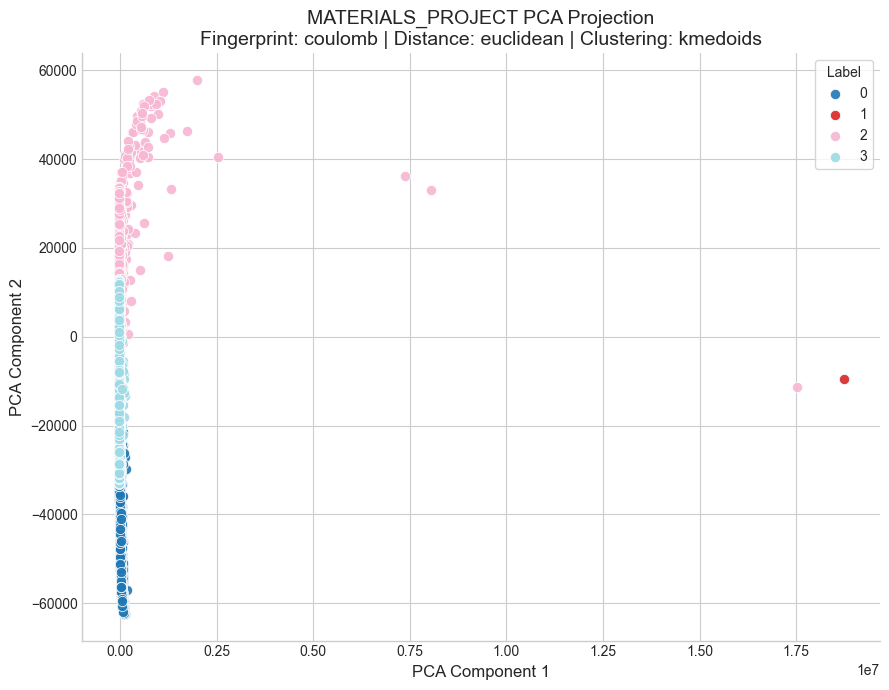

2026-04-30 16:58:42.510 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_kmedoids_projection.png


In [33]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

# Spectral

In [48]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

KeyboardInterrupt: 

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN

In [18]:
model_db = DBSCAN(
    eps=7500,
    min_samples=5,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0]), array([   9, 4991]))


In [19]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-04-30 16:56:16.111 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-30 16:56:16.114 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-30 16:56:19.727 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-30 16:56:19.740 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-30 16:56:20.450 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-04-30 16:56:20.628 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

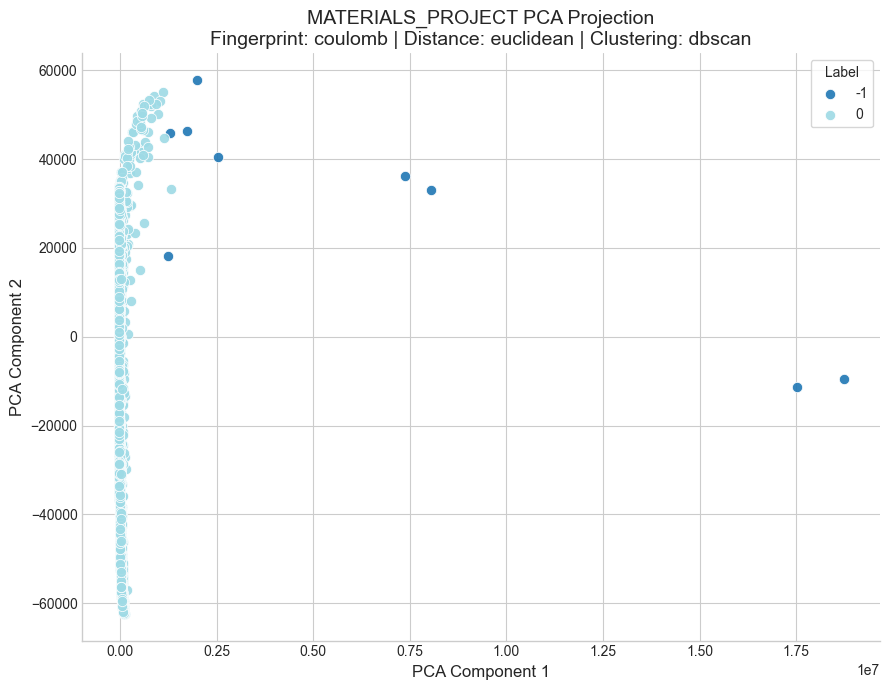

2026-04-30 16:56:22.000 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_dbscan_projection.png


{'coords': array([[ 13082.49379055, -53139.81201468],
        [-35158.54785305,  -9022.64938856],
        [-33610.6952586 ,  26440.68883965],
        ...,
        [-26412.91879261,  32297.93132736],
        [ 37089.19994577, -11728.45600105],
        [-22335.56906617, -15439.59930433]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/coulomb/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/coulomb'),
 'clustering_method': 'dbscan'}

In [20]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

In [21]:
average_numeric_by_cluster(df, "labels_db")

shape: (2, 37)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬─────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma    ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier ┆ labels_km ┆ pct_metal ┆ unique_crystal_systems ┆ top_cry

labels_db,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,is_injected,labels_hier,labels_km,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,9,1.171111,-9.566772,-0.822765,1.024922,5.450132,4.147194,4.292129,65.099332,89.51863,90.000568,113.333322,1062.102531,40.0,0.142441,2.617592,2.798623,0.0,3.444444,5.111111,44.444444,3,"""Trigonal""",77.777778,3,"""P3m1""",77.777778,6,"""AB2""",33.333333,8,"""hP12""",22.222222,1,null,0.0
0,4991,1.575925,-13.62146,-1.297566,0.54172,6.273334,6.66166,7.140102,9.116083,86.55447,87.087408,88.140118,371.991937,22.1667,0.081847,2.311322,2.575882,0.0,5.0,3.327389,60.068123,7,"""Orthorhombic""",21.799239,173,"""P1""",7.53356,923,"""ABC2""",5.950711,582,"""cF16""",3.225806,1,null,0.0


# HDBSCAN

In [44]:
a=evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=80, ms=1, clusters=2, noise=0.42, persistence=0.092, score=0.054
mcs=60, ms=1, clusters=2, noise=0.42, persistence=0.084, score=0.049
mcs=40, ms=4, clusters=2, noise=0.47, persistence=0.091, score=0.048
mcs=40, ms=1, clusters=3, noise=0.41, persistence=0.042, score=0.025
mcs=10, ms=10, clusters=4, noise=0.46, persistence=0.026, score=0.014
mcs=10, ms=10, clusters=4, noise=0.46, persistence=0.026, score=0.014
mcs=20, ms=10, clusters=4, noise=0.46, persistence=0.024, score=0.013
mcs=20, ms=10, clusters=4, noise=0.46, persistence=0.024, score=0.013
mcs=20, ms=2, clusters=5, noise=0.42, persistence=0.021, score=0.012
mcs=10, ms=1, clusters=2, noise=0.05, persistence=0.013, score=0.012
mcs=10, ms=1, clusters=2, noise=0.05, persistence=0.013, score=0.012
mcs=10, ms=7, clusters=5, noise=0.47, persistence=0.020, score=0.011
mcs=20, ms=1, clusters=8, noise=0.38, persistence=0.015, score=0.010
mcs=10, ms=2, clusters=2, noise=0.15, persistence=0.010, score=0.009


In [45]:
from hdbscan import HDBSCAN
hb = HDBSCAN(metric='precomputed', min_cluster_size=10, min_samples=1)
labels_hdbscan = hb.fit_predict(dist_matrix)
df = df.with_columns(hdbscan_labels=labels_hdbscan)

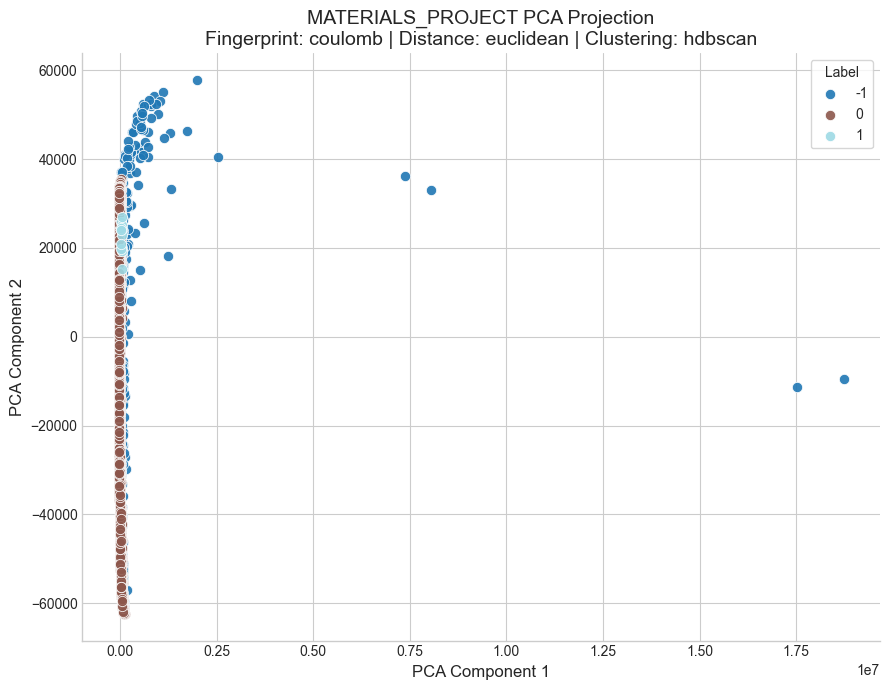

2026-04-30 17:05:23.843 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_hdbscan_projection.png


In [46]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

# KMeans on Raw Embeddings

In [23]:
from sklearn.decomposition import PCA
X = np.array(df["coulomb_matrix"].to_list(), dtype=np.float32)
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans_raw = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

ColumnNotFoundError: "coulomb_matrix" not found

In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (6, 21)
┌───────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┐
│ labels_kmeans_raw ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal │
│ ---               ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       ┆ ---       │
│ i32               ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    

labels_kmeans_raw,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1127,1.462289,-15.357988,-1.195896,0.48172,7.250105,5.869343,6.061825,8.061484,84.158394,84.305335,84.582874,216.734188,11.972493,0.084957,2.443999,2.703292,2.0,0.017746,70.186335
1,315,1.231365,-25.292602,-0.964053,0.295952,9.933522,7.593197,8.270002,9.993003,90.602551,90.562946,93.824273,503.416783,25.149206,0.033063,2.569308,2.778839,1.695238,1.0,79.047619
2,2248,1.808581,-8.06312,-1.481597,0.845961,4.252105,6.492373,6.922955,8.788828,85.847216,86.86647,87.5408,353.139131,25.105427,0.111091,2.083013,2.39822,2.0,1.8621,48.309609
3,641,1.549251,-12.799116,-1.285209,0.767241,6.167187,8.118135,8.906263,11.254611,88.992097,89.963378,93.293617,655.599515,30.842434,0.037635,2.462927,2.743731,2.0,0.928237,49.765991
4,569,1.331371,-22.804023,-1.07688,0.443418,9.054328,6.596384,7.033204,8.968662,84.807013,85.36339,92.552455,318.123401,17.630931,0.046274,2.460624,2.701295,2.0,0.977153,72.58348
5,100,1.1684,-25.477963,-0.887861,0.201496,10.660682,9.386537,9.886112,12.952253,88.494598,88.950935,92.766832,969.686963,43.19,0.024547,2.638048,2.8027,0.29,1.0,76.0


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans_raw, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…